In [1]:
import sys, os

## Include previous level directories to the module import path
sys.path.insert(0, os.path.abspath(os.path.join("..")))

# import arviz as az
import numpy as np
import h5py

# Export the results to GetDist

# Notice loadMCSamples requires a *full path*
import os
from matplotlib import pyplot as plt
import matplotlib


matplotlib.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 24,
        "axes.titlesize": 18,
        "text.usetex": True,
        "xtick.major.width": 1.5,
        "xtick.minor.width": 1.2,
        "ytick.major.width": 1.5,
        "ytick.minor.width": 1.2,
        "legend.fontsize": 18,
    }
)

# Deep purples / indigos
c_flatirons = "#440154"
c_flatirons_l = "#472d7b"
c_flatirons_ll = "#3b528b"

# Teal / cyan region
c_sunshine = "#2a788e"
c_sunshine_l = "#21908d"
c_sunshine_ll = "#20a386"

# Green-cyan (maximum brightness allowed)
c_skyline = "#35b779"
c_skyline_l = "#5ec962"  # Cap brightness here
# c_skyline_ll = omitted due to low print contrast

# Blue highlight
c_midnight = "#31688e"

In [2]:
sys.path.insert(0, os.path.abspath(os.path.join("../../DLA_data")))

In [3]:
import dla_data

In [4]:
import os.path as path

datadir = os.path.abspath(os.path.join("../../DLA_data"))


def absorption_distance():
    """Compute X(z), the absorption distance per sightline (eq. 9 of Nagamine et al 2003)
    in dimensionless units."""
    # h * 100 km/s/Mpc in h/s
    h100 = 3.2407789e-18
    # in cm/s
    light = 2.9979e10
    # Internal gadget length unit: 1 kpc/h in cm/h
    UnitLength_in_cm = 3.085678e21
    redshift = 3
    box = 25000
    # Units: h/s   s/cm                        kpc/h      cm/kpc
    return h100 / light * (1 + redshift) ** 2 * box * UnitLength_in_cm


def altay_data(label="Altay 2011"):
    """Plot the simulation cddf from Altay 2011: 1012.4014"""
    # His bins
    edges = 10 ** np.arange(17, 22.51, 0.1)
    # His data values
    cddf = np.array(
        [
            858492,
            747955,
            658685,
            582018,
            518006,
            468662,
            431614,
            406575,
            387631,
            374532,
            359789,
            350348,
            342146,
            334534,
            329178,
            324411,
            320648,
            318207,
            316232,
            314852,
            314504,
            314583,
            313942,
            315802,
            316330,
            316884,
            317336,
            317979,
            316526,
            317212,
            314774,
            309333,
            302340,
            291816,
            275818,
            254368,
            228520,
            198641,
            167671,
            135412,
            103583,
            76751,
            54326,
            37745,
            25140,
            16784,
            10938,
            6740,
            3667,
            1614,
            637,
            206,
            33,
            14,
            7,
        ]
    )
    center = np.array(
        [(edges[i] + edges[i + 1]) / 2.0 for i in range(0, np.size(edges) - 1)]
    )
    width = np.array([edges[i + 1] - edges[i] for i in range(0, np.size(edges) - 1)])
    # Grid size (in cm^2)
    dX = absorption_distance()
    tot_cells = 16384**2
    cddf = (cddf) / (width * dX * tot_cells)
    plt.loglog(center, cddf, label=label)


def altay_data_moment(label="Altay 2011"):
    """Plot the simulation cddf from Altay 2011: 1012.4014"""
    # His bins
    edges = 10 ** np.arange(17, 22.51, 0.1)
    # His data values
    cddf = np.array(
        [
            858492,
            747955,
            658685,
            582018,
            518006,
            468662,
            431614,
            406575,
            387631,
            374532,
            359789,
            350348,
            342146,
            334534,
            329178,
            324411,
            320648,
            318207,
            316232,
            314852,
            314504,
            314583,
            313942,
            315802,
            316330,
            316884,
            317336,
            317979,
            316526,
            317212,
            314774,
            309333,
            302340,
            291816,
            275818,
            254368,
            228520,
            198641,
            167671,
            135412,
            103583,
            76751,
            54326,
            37745,
            25140,
            16784,
            10938,
            6740,
            3667,
            1614,
            637,
            206,
            33,
            14,
            7,
        ]
    )
    center = np.array(
        [(edges[i] + edges[i + 1]) / 2.0 for i in range(0, np.size(edges) - 1)]
    )
    width = np.array([edges[i + 1] - edges[i] for i in range(0, np.size(edges) - 1)])
    # Grid size (in cm^2)
    dX = absorption_distance()
    tot_cells = 16384**2
    cddf = (cddf) / (width * dX * tot_cells)
    plt.loglog(center, cddf * center, label=label)


def prochaska_10_data(moment=False, label="Prochaska 2010"):
    """Plot the LLS only data of Prochaska 2010, given as a box rather than the more conventional error bars.
    This is at z=3.7"""
    data = np.loadtxt(path.join(datadir, "prochaska_lls.dat"))
    ax = plt.gca()
    cddf = data[:, 1]
    if moment:
        cddf += data[:, 0]
    ax.fill(10.0 ** data[:, 0], 10.0**cddf, "grey", label=label)


def zafar_data(moment=False, label="Zafar 2013"):
    """Plot Zafar & Peroux data on LLS at z=1.5 - 5.
    This is 1307.0602.
    Format: x, y, xerr, yerr (in logspace)"""
    data = np.loadtxt(path.join(datadir, "zafar_2013.txt"))
    # Madness to put log errors into non-log
    NHI = 10 ** data[:, 0]
    cddf = 10 ** data[:, 2]
    uxer = 10 ** (data[:, 1] + data[:, 0]) - 10 ** data[:, 0]
    lxer = -(10 ** (-data[:, 1] + data[:, 0])) + 10 ** data[:, 0]
    uyer = 10 ** (data[:, 3] + data[:, 2]) - 10 ** data[:, 2]
    lyer = -(10 ** (-data[:, 4] + data[:, 2])) + 10 ** data[:, 2]
    if moment:
        lyer *= NHI
        uyer *= NHI
        cddf *= NHI
    plt.errorbar(
        NHI,
        cddf,
        xerr=[lxer, uxer],
        yerr=[lyer, uyer],
        fmt="o",
        color="grey",
        ms=5,
        label=label,
    )


def ho21_cddf(redshift=-1, moment=False, onesigma=False, label="Ho21"):
    """Plot the CDDF from https://arxiv.org/abs/2103.10964
    moment: if true plot Nf(N)
    onesigma: if true plot 68% confidence. If false plot 95% confidence"""
    if redshift < 0:
        cfile = "ho21/cddf_all.txt"
    elif 2 <= redshift < 2.5:
        cfile = "ho21/cddf_z225.txt"
    elif 2.5 <= redshift < 3:
        cfile = "ho21/cddf_z253.txt"
    elif 3 <= redshift < 4:
        cfile = "ho21/cddf_z253.txt"
    elif 4 <= redshift < 5:
        cfile = "ho21/cddf_z45.txt"
    else:
        raise ValueError("No CDDF at redshift %.2g", redshift)
    data = np.loadtxt(path.join(datadir, cfile)).T
    NHI = 10 ** data[:, 0]
    cddf = data[:, 1]
    if onesigma:
        lyer = data[:, 2]
        uyer = data[:, 3]
    else:
        lyer = data[:, 4]
        uyer = data[:, 5]
    if moment:
        lyer *= NHI
        uyer *= NHI
        cddf *= NHI
    plt.errorbar(
        NHI,
        cddf,
        yerr=[cddf - lyer, uyer - cddf],
        fmt="o",
        color="black",
        ms=5,
        label=label,
    )
    plt.yscale("log")
    plt.xscale("log")

import numpy as np
from scipy.interpolate import PchipInterpolator

# From Table 2 (Results for Spline Model — Figure 7)
logN_nodes = np.array([12.0, 15.0, 17.0, 18.0, 
                       20.0, 21.0, 21.5, 22.0])
logf_nodes = np.array([-9.72, -14.41, -17.94, -19.39,
                       -21.28, -22.82, -23.95, -25.50])

# Paper specifies cubic Hermite spline (Fritsch & Carlson 1980)
cddf_spline = PchipInterpolator(logN_nodes, logf_nodes)

def log10_f_cddf(logN):
    """
    CDDF used in Figure 7 of Prochaska et al. 2014.
    A cubic Hermite spline defined by Table 2 (Spline Model).
    """
    logN = np.asarray(logN)
    logN_clip = np.clip(logN, logN_nodes[0], logN_nodes[-1])
    return cddf_spline(logN_clip)

def f_cddf(logN):
    return 10**log10_f_cddf(logN)

# plot the CDDF from Prochaska et al. 2014
# logN_plot = np.linspace(12.0, 22.0, 500)
# plt.plot(logN_plot, f_cddf(logN_plot), label="Prochaska et al. 2014 CDDF")
# plt.yscale("log")
# plt.xlabel(r"$\log_{10} N_{\mathrm{HI}}$ [cm$^{-2}$]")
# plt.ylabel(r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]")
# plt.title("Column Density Distribution Function (CDDF)")
# plt.legend()

## GP London mock measurement : f^meas

In [5]:
### London mock : CDDF prior is from Prochaska et al. 2014
############## DLA run ################
### Somehow SNR > 6 is less biased than SNR > 8
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0/"
# SNR > 8 run
# subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_london_cddf_nhi172_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0"

############# Loading z separately for diff z bins #################

# Load Cddf
############# z = 2.0 - 2.5 bin ################
cddf_mock_z2025 = np.loadtxt(os.path.join(subdir, "cddf_z225.txt"))
(_, N) = cddf_mock_z2025.shape

cddf68_mock_z2025 = np.full((N, 2), fill_value=np.nan)
cddf95_mock_z2025 = np.full((N, 2), fill_value=np.nan)
(l_N_z2025, cddf_z2025, cddf68_mock_z2025[:, 0], cddf68_mock_z2025[:, 1], cddf95_mock_z2025[:, 0], cddf95_mock_z2025[:, 1]) = cddf_mock_z2025

############# z = 2.5 - 3.0 bin ################
cddf_mock_z2530 = np.loadtxt(os.path.join(subdir, "cddf_z2530.txt"))
(_, N) = cddf_mock_z2530.shape

cddf68_mock_z2530 = np.full((N, 2), fill_value=np.nan)
cddf95_mock_z2530 = np.full((N, 2), fill_value=np.nan)
(l_N_z2530, cddf_z2530, cddf68_mock_z2530[:, 0], cddf68_mock_z2530[:, 1], cddf95_mock_z2530[:, 0], cddf95_mock_z2530[:, 1]) = cddf_mock_z2530

############# z = 3.0 - 3.5 bin ################
cddf_mock_z3035 = np.loadtxt(os.path.join(subdir, "cddf_z3035.txt"))
(_, N) = cddf_mock_z3035.shape

cddf68_mock_z3035 = np.full((N, 2), fill_value=np.nan)
cddf95_mock_z3035 = np.full((N, 2), fill_value=np.nan)
(l_N_z3035, cddf_z3035, cddf68_mock_z3035[:, 0], cddf68_mock_z3035[:, 1], cddf95_mock_z3035[:, 0], cddf95_mock_z3035[:, 1]) = cddf_mock_z3035

############# z = 3.5 - 4.0 bin ################
cddf_mock_z3540 = np.loadtxt(os.path.join(subdir, "cddf_z3540.txt"))
(_, N) = cddf_mock_z3540.shape

cddf68_mock_z3540 = np.full((N, 2), fill_value=np.nan)
cddf95_mock_z3540 = np.full((N, 2), fill_value=np.nan)
(l_N_z3540, cddf_z3540, cddf68_mock_z3540[:, 0], cddf68_mock_z3540[:, 1], cddf95_mock_z3540[:, 0], cddf95_mock_z3540[:, 1]) = cddf_mock_z3540

In [6]:
# Measurement logN mids
logN_mids_meas = l_N_z2025.copy()
print("Measurement logN mids:", logN_mids_meas)

# convert mids to bins
def logN_bins_from_mids(logN_mids):
    logN_edges = np.zeros(len(logN_mids) + 1)
    logN_edges[1:-1] = (logN_mids[:-1] + logN_mids[1:]) / 2
    logN_edges[0] = logN_mids[0] - (logN_mids[1] - logN_mids[0]) / 2
    logN_edges[-1] = logN_mids[-1] + (logN_mids[-1] - logN_mids[-2]) / 2
    return logN_edges

logN_bins_meas = logN_bins_from_mids(logN_mids_meas)
print("Measurement logN bins:", logN_bins_meas)

Measurement logN mids: [17.28 17.44 17.6  17.76 17.92 18.08 18.24 18.4  18.56 18.72 18.88 19.04
 19.2  19.36 19.52 19.68 19.84 20.   20.16 20.32 20.48 20.64 20.8  20.96
 21.12 21.28 21.44 21.6  21.76 21.92]
Measurement logN bins: [17.2  17.36 17.52 17.68 17.84 18.   18.16 18.32 18.48 18.64 18.8  18.96
 19.12 19.28 19.44 19.6  19.76 19.92 20.08 20.24 20.4  20.56 20.72 20.88
 21.04 21.2  21.36 21.52 21.68 21.84 22.  ]


## Truth table: CDDF, f_truth

In [7]:
from astropy.table import Table
# CDDF mock code
from CDDF_analysis.cddf_mock import *

dla_cat = Table.read(
    "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/data/london/dla_cat.fits"
)
qso_cat = Table.read(
    "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/data/london/zcat.fits"
)

In [8]:
import numpy as np

def zbins_from_zmid_uniform(z_mid):
    z_mid = np.asarray(z_mid, dtype=float)
    dz = np.median(np.diff(z_mid))   # robust
    zbins = np.concatenate([
        [z_mid[0] - 0.5 * dz],
        z_mid + 0.5 * dz
    ])
    return zbins

# --- choose redshift bins ---
zbins = np.array([2.0, 2.5, 3.0, 3.5, 4.0])
# zbins = zbins_from_zmid_uniform(z_cent)

# --- common analysis settings ---
# common = dict(
#     zbins=zbins,
#     zmin=2.0,
#     zmax_global=None,
#     v_prox_kms=3000.0,
#     Omega_m=0.279,
#     assume_logNHI=True,
#     n_boot=200,   # set 0 to skip bootstrap
# )

##### Use meas bins instead 
# logN_bins_lls = np.arange(17.2, 22 + 1e-6, 0.2)
logN_bins_lls = logN_bins_meas # same bins as the measurement for direct comparison

cddf_lls = compute_cddf_fN(
    dla_cat, qso_cat,
    zbins=zbins,
    logN_bins=logN_bins_lls,

    # search-window settings
    zmin=2.15,                 # do not hard-code 2.0 as the only lower limit
    zmax_global=None,
    v_prox_kms=3000.0,         # proximity cut
    absorber_rest=1215.67,     # z_DLA defined using Lyα
    blue_limit_mode="max",     # use max of all lower-bound cuts
    blue_rest=1025.72,         # Lyβ blue cutoff
    lambda_obs_min=3600.0,     # DESI blue wavelength cutoff
    lambda_obs_max=None,

    # cosmology / absorber selection
    Omega_m=0.279,
    logNHImin=17.2,
    logNHImax=22.0,
    assume_logNHI=True,
    n_boot=200,
)

In [9]:
print("LLS CDDF zmids:", cddf_lls["z_mid"])
print("LLS CDDF logN bins:", cddf_lls["logN_mid"])
print("Measured logN mids:", logN_mids_meas)
assert np.allclose(cddf_lls["logN_mid"], logN_mids_meas), "LLS CDDF logN mids do not match measurement logN mids"

LLS CDDF zmids: [2.25 2.75 3.25 3.75]
LLS CDDF logN bins: [17.28 17.44 17.6  17.76 17.92 18.08 18.24 18.4  18.56 18.72 18.88 19.04
 19.2  19.36 19.52 19.68 19.84 20.   20.16 20.32 20.48 20.64 20.8  20.96
 21.12 21.28 21.44 21.6  21.76 21.92]
Measured logN mids: [17.28 17.44 17.6  17.76 17.92 18.08 18.24 18.4  18.56 18.72 18.88 19.04
 19.2  19.36 19.52 19.68 19.84 20.   20.16 20.32 20.48 20.64 20.8  20.96
 21.12 21.28 21.44 21.6  21.76 21.92]


In [10]:
cddf_lls.keys()

dict_keys(['z_mid', 'zbins', 'logN_mid', 'logN_bins', 'N_mid', 'N_edges', 'dN', 'fN', 'err_poisson', 'err_boot', 'counts', 'X_tot', 'meta'])

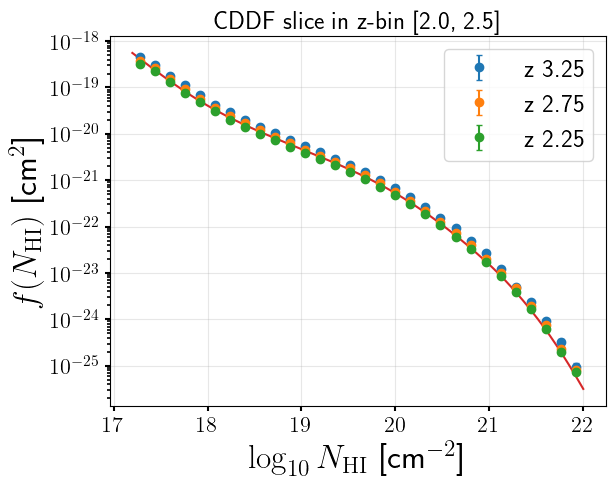

In [11]:
# ------------------------------------------------------------
# 4) Plot one redshift slice of CDDF (overlay)
# Choose z-bin index k (0..len(zbins)-2)
# Example: k=2 corresponds to zbins[2]..zbins[3] = 3.0..3.5
# ------------------------------------------------------------

fig, ax = plt.subplots()
k = 2
plot_cddf_slice_fN(
    cddf_lls, k,
    label=f"z~{cddf_lls['z_mid'][k]:.2f}",
    prefer_boot=True, ax=ax, show=False, ylog=True
)

k = 1
plot_cddf_slice_fN(
    cddf_lls, k,
    label=f"z~{cddf_lls['z_mid'][k]:.2f}",
    prefer_boot=True, ax=ax, show=False, ylog=True
)

k = 0
plot_cddf_slice_fN(
    cddf_lls, k,
    label=f"z~{cddf_lls['z_mid'][k]:.2f}",
    prefer_boot=True, ax=ax, show=False, ylog=True
)

# plot_cddf_slice_fN(
#     cddf_sub, k,
#     label=f"subDLA z~{cddf_sub['z_mid'][k]:.2f}",
#     prefer_boot=True, ax=ax, show=False, ylog=True
# )
# plot_cddf_slice_fN(
#     cddf_dla, k,
#     label=f"DLA  z~{cddf_dla['z_mid'][k]:.2f}",
#     prefer_boot=True, ax=ax, show=False, ylog=True
# )

# plot the CDDF from Prochaska et al. 2014
logN_plot = np.linspace(17.2, 22.0, 500)
plt.plot(logN_plot, f_cddf(logN_plot), label="Prochaska et al. 2014 CDDF")
plt.yscale("log")
plt.xlabel(r"$\log_{10} N_{\mathrm{HI}}$ [cm$^{-2}$]")
plt.ylabel(r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]")
plt.title("Column Density Distribution Function (CDDF)")

ax.set_title(f"CDDF slice in z-bin [{zbins[k]}, {zbins[k+1]}]")
plt.show()


## My GP London Mock runs

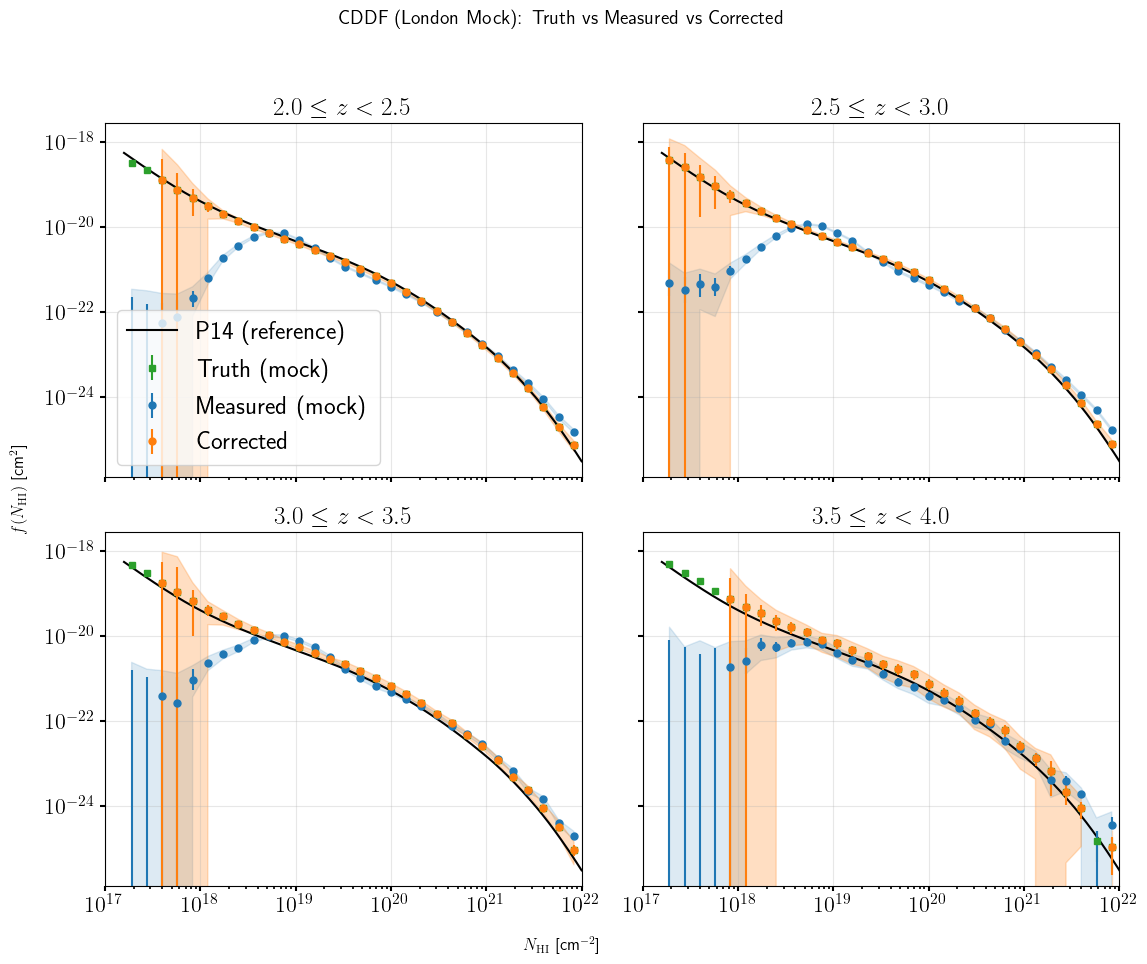

In [12]:
# ============================================================
# Completeness / recovery correction using truth-table CDDF
#
# We now use:
#   r_{k,i} = f_true_mock(k,i) / f_meas_mock(k,i)
#
# and apply it to a measured CDDF:
#   f_corr = r * f_meas
#
# Uncertainty propagation (approximate; assumes independence):
#   (sigma_r / r)^2     = (sigma_true / f_true)^2 + (sigma_meas_mock / f_meas_mock)^2
#   (sigma_corr / f_corr)^2 = (sigma_apply / f_apply)^2 + (sigma_r / r)^2
#
# NOTE:
# If you apply the ratio derived from the same mock measurement back onto that
# same mock measurement, this ignores covariance and is therefore approximate,
# usually conservative. For applying mock-derived r to real data, this is the
# standard practical approximation.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# helper: choose truth uncertainty from cddf_lls
# ----------------------------
def get_truth_sigma(out_cddf, prefer_boot=True):
    if prefer_boot and (out_cddf.get("err_boot") is not None):
        return np.asarray(out_cddf["err_boot"], dtype=float)
    return np.asarray(out_cddf["err_poisson"], dtype=float)


# ----------------------------
# helper: turn [low, high] intervals into symmetric sigma
# ----------------------------
def sigma_from_interval(y, interval):
    """
    Convert an interval [low, high] into an approximate symmetric sigma:
        sigma ~= 0.5 * (high - low)

    Parameters
    ----------
    y : array-like
        Central values (not directly used except for shape checking)
    interval : (N,2) array
        Lower/upper interval
    """
    y = np.asarray(y, dtype=float)
    interval = np.asarray(interval, dtype=float)
    sig = 0.5 * (interval[:, 1] - interval[:, 0])
    sig[~np.isfinite(sig)] = np.nan
    return sig


# ----------------------------
# build correction ratio with uncertainty
# ----------------------------
def correction_ratio_with_uncertainty(f_true, sig_true, f_meas_mock, sig_meas_mock):
    """
    r = f_true / f_meas_mock
    sigma_r / r = sqrt[(sigma_true/f_true)^2 + (sigma_meas_mock/f_meas_mock)^2]
    """
    f_true = np.asarray(f_true, dtype=float)
    sig_true = np.asarray(sig_true, dtype=float)
    f_meas_mock = np.asarray(f_meas_mock, dtype=float)
    sig_meas_mock = np.asarray(sig_meas_mock, dtype=float)

    r = np.full_like(f_true, np.nan)
    sig_r = np.full_like(f_true, np.nan)

    m = (
        np.isfinite(f_true) & np.isfinite(sig_true) &
        np.isfinite(f_meas_mock) & np.isfinite(sig_meas_mock) &
        (f_true > 0) & (f_meas_mock > 0)
    )

    r[m] = f_true[m] / f_meas_mock[m]

    frac_true = np.zeros_like(f_true)
    frac_meas = np.zeros_like(f_true)
    frac_true[m] = sig_true[m] / f_true[m]
    frac_meas[m] = sig_meas_mock[m] / f_meas_mock[m]

    sig_r[m] = r[m] * np.sqrt(frac_true[m]**2 + frac_meas[m]**2)
    return r, sig_r


# ----------------------------
# apply correction to a measured CDDF with uncertainty
# ----------------------------
def apply_correction_with_uncertainty(f_apply, sig_apply, r, sig_r, nsig=1.0):
    """
    f_corr = r * f_apply
    sigma_corr / f_corr = sqrt[(sigma_apply/f_apply)^2 + (sigma_r/r)^2]

    Returns
    -------
    f_corr : array
    sig_corr : array
    interval : (N,2) array
        symmetric interval [f_corr - nsig*sigma, f_corr + nsig*sigma]
        lower bound clipped at 0
    """
    f_apply = np.asarray(f_apply, dtype=float)
    sig_apply = np.asarray(sig_apply, dtype=float)
    r = np.asarray(r, dtype=float)
    sig_r = np.asarray(sig_r, dtype=float)

    f_corr = np.full_like(f_apply, np.nan)
    sig_corr = np.full_like(f_apply, np.nan)

    m = (
        np.isfinite(f_apply) & np.isfinite(sig_apply) &
        np.isfinite(r) & np.isfinite(sig_r) &
        (f_apply > 0) & (r > 0)
    )

    f_corr[m] = r[m] * f_apply[m]

    frac_apply = np.zeros_like(f_apply)
    frac_r = np.zeros_like(f_apply)
    frac_apply[m] = sig_apply[m] / f_apply[m]
    frac_r[m] = sig_r[m] / r[m]

    sig_corr[m] = f_corr[m] * np.sqrt(frac_apply[m]**2 + frac_r[m]**2)

    lo = f_corr - nsig * sig_corr
    hi = f_corr + nsig * sig_corr
    lo = np.where(np.isfinite(lo), np.maximum(lo, 0.0), np.nan)

    return f_corr, sig_corr, np.column_stack([lo, hi])


# ----------------------------
# sanity checks: truth table bins must match measurement bins
# ----------------------------
truth_logN_mid = np.asarray(cddf_lls["logN_mid"], dtype=float)
truth_z_mid = np.asarray(cddf_lls["z_mid"], dtype=float)
truth_fN = np.asarray(cddf_lls["fN"], dtype=float)
truth_sigma = get_truth_sigma(cddf_lls, prefer_boot=True)

if not np.allclose(truth_logN_mid, l_N_z2025):
    raise ValueError("Truth-table logN_mid does not match l_N_z2025 measurement bins.")
if not np.allclose(truth_logN_mid, l_N_z2530):
    raise ValueError("Truth-table logN_mid does not match l_N_z2530 measurement bins.")
if not np.allclose(truth_logN_mid, l_N_z3035):
    raise ValueError("Truth-table logN_mid does not match l_N_z3035 measurement bins.")
if not np.allclose(truth_logN_mid, l_N_z3540):
    raise ValueError("Truth-table logN_mid does not match l_N_z3540 measurement bins.")

expected_zmid = np.array([2.25, 2.75, 3.25, 3.75])
if not np.allclose(truth_z_mid, expected_zmid):
    print("Warning: truth z_mid =", truth_z_mid, "but expected", expected_zmid)


# ----------------------------
# measured mock uncertainties from existing intervals
# ----------------------------
sig68_meas_z2025  = sigma_from_interval(cddf_z2025,  cddf68_mock_z2025)
sig68_meas_z2530  = sigma_from_interval(cddf_z2530,  cddf68_mock_z2530)
sig68_meas_z3035  = sigma_from_interval(cddf_z3035,  cddf68_mock_z3035)
sig68_meas_z3540  = sigma_from_interval(cddf_z3540,  cddf68_mock_z3540)



# ----------------------------
# truth slices from cddf_lls
# rows correspond to zbins = [2.0-2.5, 2.5-3.0, 3.0-3.5, 3.5-4.0]
# ----------------------------
f_true_z2025,  sig_true_z2025  = truth_fN[0], truth_sigma[0]
f_true_z2530, sig_true_z2530 = truth_fN[1], truth_sigma[1]
f_true_z3035, sig_true_z3035 = truth_fN[2], truth_sigma[2]
f_true_z3540, sig_true_z3540 = truth_fN[3], truth_sigma[3]


# ----------------------------
# build correction ratios using mock truth / mock measured
# ----------------------------
r_mock_z2025,  sig_r_mock_z2025  = correction_ratio_with_uncertainty(f_true_z2025,  sig_true_z2025,  cddf_z2025,  sig68_meas_z2025)
r_mock_z2530, sig_r_mock_z2530 = correction_ratio_with_uncertainty(f_true_z2530, sig_true_z2530, cddf_z2530, sig68_meas_z2530)
r_mock_z3035, sig_r_mock_z3035 = correction_ratio_with_uncertainty(f_true_z3035, sig_true_z3035, cddf_z3035, sig68_meas_z3035)
r_mock_z3540, sig_r_mock_z3540 = correction_ratio_with_uncertainty(f_true_z3540, sig_true_z3540, cddf_z3540, sig68_meas_z3540)


# ----------------------------
# apply correction to the measured mock CDDF
# if later applying to real data, replace cddf_zXX and sig68_meas_zXX
# with the real-data measurement and its uncertainty
# ----------------------------
cddf_z2025_corrected,  sig_corr_z2025,  cddf68_mock_z2025_corrected  = apply_correction_with_uncertainty(cddf_z2025,  sig68_meas_z2025,  r_mock_z2025,  sig_r_mock_z2025,  nsig=1.0)
cddf_z2530_corrected, sig_corr_z2530, cddf68_mock_z2530_corrected = apply_correction_with_uncertainty(cddf_z2530, sig68_meas_z2530, r_mock_z2530, sig_r_mock_z2530, nsig=1.0)
cddf_z3035_corrected, sig_corr_z3035, cddf68_mock_z3035_corrected = apply_correction_with_uncertainty(cddf_z3035, sig68_meas_z3035, r_mock_z3035, sig_r_mock_z3035, nsig=1.0)
cddf_z3540_corrected, sig_corr_z3540, cddf68_mock_z3540_corrected = apply_correction_with_uncertainty(cddf_z3540, sig68_meas_z3540, r_mock_z3540, sig_r_mock_z3540, nsig=1.0)

# 95% bands from the same propagated sigma
_, _, cddf95_mock_z2025_corrected  = apply_correction_with_uncertainty(cddf_z2025,  sig68_meas_z2025,  r_mock_z2025,  sig_r_mock_z2025,  nsig=2.0)
_, _, cddf95_mock_z2530_corrected = apply_correction_with_uncertainty(cddf_z2530, sig68_meas_z2530, r_mock_z2530, sig_r_mock_z2530, nsig=2.0)
_, _, cddf95_mock_z3035_corrected = apply_correction_with_uncertainty(cddf_z3035, sig68_meas_z3035, r_mock_z3035, sig_r_mock_z3035, nsig=2.0)
_, _, cddf95_mock_z3540_corrected = apply_correction_with_uncertainty(cddf_z3540, sig68_meas_z3540, r_mock_z3540, sig_r_mock_z3540, nsig=2.0)


# ----------------------------
# plot
# ----------------------------
# ----------------------------
# multi-panel plot (one panel per z-bin)
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

z_labels = [
    "$ 2.0 \leq z < 2.5$",
    "$ 2.5 \leq z < 3.0$",
    "$ 3.0 \leq z < 3.5$",
    "$ 3.5 \leq z < 4.0$",
]

# collect everything into lists for loop
logN_list = [l_N_z2025, l_N_z2530, l_N_z3035, l_N_z3540]

f_meas_list = [cddf_z2025, cddf_z2530, cddf_z3035, cddf_z3540]
f68_meas_list = [cddf68_mock_z2025, cddf68_mock_z2530, cddf68_mock_z3035, cddf68_mock_z3540]
f95_meas_list = [cddf95_mock_z2025, cddf95_mock_z2530, cddf95_mock_z3035, cddf95_mock_z3540]

f_corr_list = [cddf_z2025_corrected, cddf_z2530_corrected, cddf_z3035_corrected, cddf_z3540_corrected]
f68_corr_list = [cddf68_mock_z2025_corrected, cddf68_mock_z2530_corrected, cddf68_mock_z3035_corrected, cddf68_mock_z3540_corrected]
f95_corr_list = [cddf95_mock_z2025_corrected, cddf95_mock_z2530_corrected, cddf95_mock_z3035_corrected, cddf95_mock_z3540_corrected]

f_true_list = [f_true_z2025, f_true_z2530, f_true_z3035, f_true_z3540]
sig_true_list = [sig_true_z2025, sig_true_z2530, sig_true_z3035, sig_true_z3540]

# P14 reference
logN_plot = np.linspace(17.2, 22.0, 500)
N_plot = 10**logN_plot
f_p14 = f_cddf(logN_plot)

for i, ax in enumerate(axes):
    logN = logN_list[i]
    N = 10.0 ** logN

    # --- P14 reference ---
    ax.plot(N_plot, f_p14, color="black", lw=1.5,
            label="P14 (reference)" if i == 0 else None)

    # --- truth ---
    ax.errorbar(
        10.0**truth_logN_mid,
        f_true_list[i],
        yerr=sig_true_list[i],
        fmt="s",
        color="C2",
        ms=4,
        label="Truth (mock)" if i == 0 else None,
    )

    # --- measured ---
    ax.errorbar(
        N,
        f_meas_list[i],
        yerr=[
            f_meas_list[i] - f68_meas_list[i][:, 0],
            f68_meas_list[i][:, 1] - f_meas_list[i],
        ],
        fmt="o",
        color="C0",
        ms=5,
        label="Measured (mock)" if i == 0 else None,
    )

    ax.fill_between(
        N,
        f95_meas_list[i][:, 0],
        f95_meas_list[i][:, 1],
        color="C0",
        alpha=0.15,
    )

    # --- corrected ---
    ax.errorbar(
        N,
        f_corr_list[i],
        yerr=[
            f_corr_list[i] - f68_corr_list[i][:, 0],
            f68_corr_list[i][:, 1] - f_corr_list[i],
        ],
        fmt="o",
        color="C1",
        ms=5,
        label="Corrected" if i == 0 else None,
    )

    ax.fill_between(
        N,
        f95_corr_list[i][:, 0],
        f95_corr_list[i][:, 1],
        color="C1",
        alpha=0.25,
    )

    # --- styling ---
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e17, 1e22)
    ax.set_title(z_labels[i])
    ax.grid(True, alpha=0.3)

# shared labels
fig.text(0.5, 0.04, r"$N_{\mathrm{HI}}$ [cm$^{-2}$]", ha="center", fontsize=12)
fig.text(0.04, 0.5, r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]", va="center", rotation="vertical", fontsize=12)

# legend only once
axes[0].legend()

plt.suptitle("CDDF (London Mock): Truth vs Measured vs Corrected", fontsize=14)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.96])
plt.show()

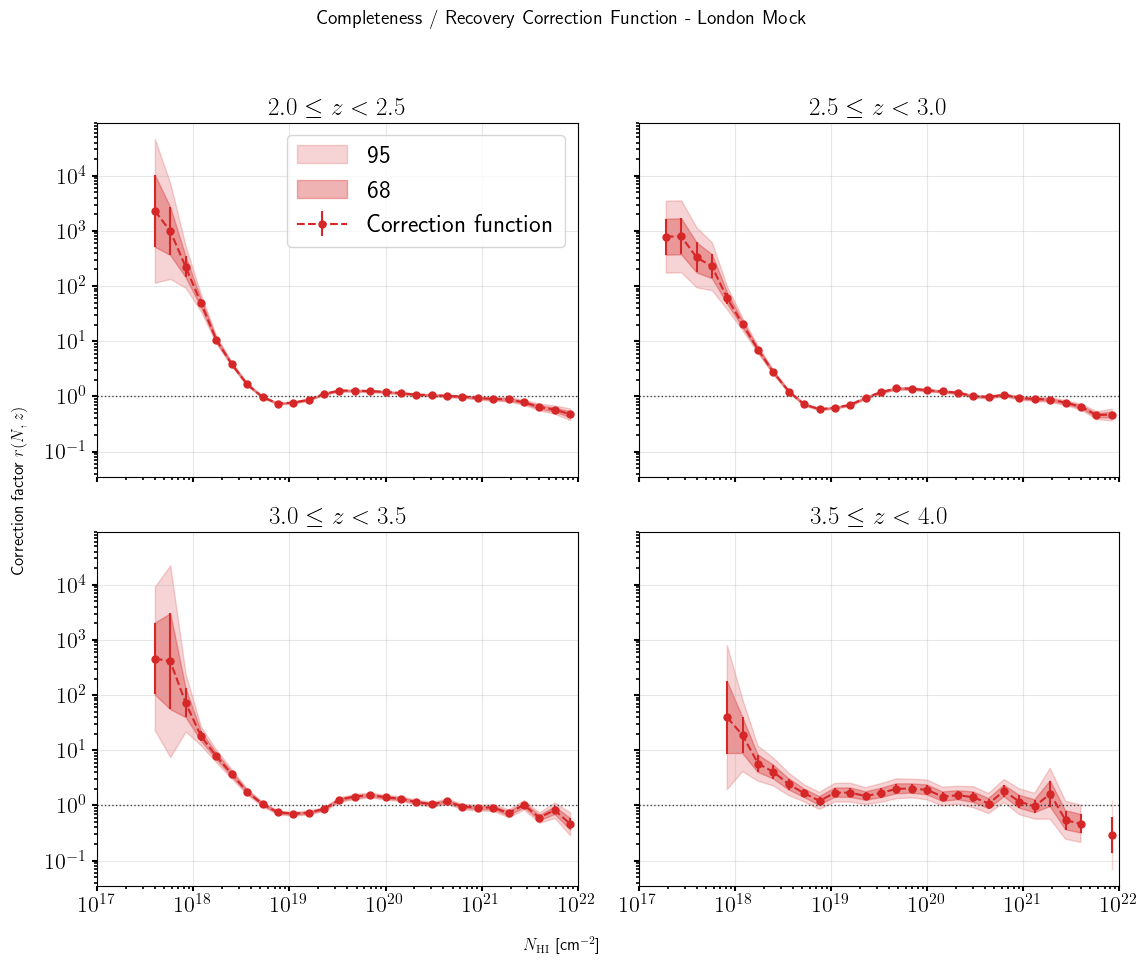

In [13]:
# ============================================================
# Correction function r(N,z) in a 2x2 grid
#
# Uses:
#   r_mock_z25,  sig_r_mock_z25
#   r_mock_z253, sig_r_mock_z253
#   r_mock_z335, sig_r_mock_z335
#   r_mock_z354, sig_r_mock_z354
#
# These should already have been computed from:
#   r = f_true_mock / f_meas_mock
# with propagated uncertainty.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def make_log_interval(y, sigma, nsig=1.0):
    """
    Build multiplicative interval in log-space:
        log10 y ± nsig * sigma_log10

    where
        sigma_log10 = sigma / (y ln 10)

    This is often nicer for ratios plotted on log scale.
    """
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    out = np.full((len(y), 2), np.nan, dtype=float)

    m = np.isfinite(y) & np.isfinite(sigma) & (y > 0)
    sigma_log10 = np.zeros_like(y)
    sigma_log10[m] = sigma[m] / (y[m] * np.log(10.0))

    out[m, 0] = 10 ** (np.log10(y[m]) - nsig * sigma_log10[m])
    out[m, 1] = 10 ** (np.log10(y[m]) + nsig * sigma_log10[m])
    return out


# Build 68% / 95% intervals for correction ratio in log-space
r68_z2025  = make_log_interval(r_mock_z2025,  sig_r_mock_z2025,  nsig=1.0)
r95_z2025  = make_log_interval(r_mock_z2025,  sig_r_mock_z2025,  nsig=2.0)

r68_z2530 = make_log_interval(r_mock_z2530, sig_r_mock_z2530, nsig=1.0)
r95_z2530 = make_log_interval(r_mock_z2530, sig_r_mock_z2530, nsig=2.0)

r68_z3035 = make_log_interval(r_mock_z3035, sig_r_mock_z3035, nsig=1.0)
r95_z3035 = make_log_interval(r_mock_z3035, sig_r_mock_z3035, nsig=2.0)

r68_z3540 = make_log_interval(r_mock_z3540, sig_r_mock_z3540, nsig=1.0)
r95_z3540 = make_log_interval(r_mock_z3540, sig_r_mock_z3540, nsig=2.0)


fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

z_labels = [
    "$ 2.0 \leq z < 2.5$",
    "$ 2.5 \leq z < 3.0$",
    "$ 3.0 \leq z < 3.5$",
    "$ 3.5 \leq z < 4.0$",
]

logN_list = [l_N_z2025, l_N_z2530, l_N_z3035, l_N_z3540]
r_list = [r_mock_z2025, r_mock_z2530, r_mock_z3035, r_mock_z3540]
r68_list = [r68_z2025, r68_z2530, r68_z3035, r68_z3540]
r95_list = [r95_z2025, r95_z2530, r95_z3035, r95_z3540]

for i, ax in enumerate(axes):
    logN = logN_list[i]
    N = 10.0 ** logN
    r = r_list[i]
    r68 = r68_list[i]
    r95 = r95_list[i]

    # 95% band
    ax.fill_between(
        N,
        r95[:, 0],
        r95[:, 1],
        color="C3",
        alpha=0.20,
        label="95%" if i == 0 else None,
    )

    # 68% band
    ax.fill_between(
        N,
        r68[:, 0],
        r68[:, 1],
        color="C3",
        alpha=0.35,
        label="68%" if i == 0 else None,
    )

    # central value
    ax.errorbar(
        N,
        r,
        yerr=[
            r - r68[:, 0],
            r68[:, 1] - r,
        ],
        fmt="o",
        color="C3",
        ms=5,
        linestyle="--",
        label="Correction function" if i == 0 else None,
    )

    # reference line r = 1
    ax.axhline(1.0, color="black", lw=1.0, alpha=0.7, linestyle=":")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e17, 1e22)
    ax.set_title(z_labels[i])
    ax.grid(True, alpha=0.3)

fig.text(0.5, 0.04, r"$N_{\mathrm{HI}}$ [cm$^{-2}$]", ha="center", fontsize=12)
fig.text(0.04, 0.5, r"Correction factor $r(N,z)$", va="center", rotation="vertical", fontsize=12)

axes[0].legend()
plt.suptitle("Completeness / Recovery Correction Function - London Mock", fontsize=14)
plt.tight_layout(rect=[0.05, 0.05, 1, 0.96])
plt.show()

My DESI DLA runs

In [14]:
############## DLA run ################
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/dla_cddf/dla_cddf_20250302/desi_snr4.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_lowzcut_zminlyb_highnhi_21.5_minobswave_3700.0_bins_3/"
# high_snrsubdir = "../dla_cddf/dla_cddf_20250302/desi_snr6.0_zqsos_2.5-6.0_dla_5.5_occam_1.0_dla_model_3_subdla_lowzcut_zminlyb_highnhi_21.5_minobswave_3700.0_bins_3/"
outfile = "../cddf_all/"

# Load Cddf
cddf_all = np.loadtxt(os.path.join(subdir, "cddf_all.txt"))
(_, N) = cddf_all.shape

cddf68 = np.full((N, 2), fill_value=np.nan)
cddf95 = np.full((N, 2), fill_value=np.nan)
(l_N, cddf, cddf68[:, 0], cddf68[:, 1], cddf95[:, 0], cddf95[:, 1]) = cddf_all

############### LLS run ################
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_17.2-19.0_z_dla_cddf_min_1.0_z_dla_dndx_min_2.0/"
# load Cddf

#### z = 2.0 - 2.5 bin ################
cddf_all_z2025 = np.loadtxt(os.path.join(subdir, "cddf_z225.txt"))
(_, N) = cddf_all_z2025.shape

cddf68_lls_z2025 = np.full((N, 2), fill_value=np.nan)
cddf95_lls_z2025 = np.full((N, 2), fill_value=np.nan)
(l_N_lls_z2025, cddf_lls_z2025, cddf68_lls_z2025[:, 0], cddf68_lls_z2025[:, 1], cddf95_lls_z2025[:, 0], cddf95_lls_z2025[:, 1]) = cddf_all_z2025

#### z = 2.5 - 3.0 bin ################
cddf_all_z2530 = np.loadtxt(os.path.join(subdir, "cddf_z2530.txt"))
(_, N) = cddf_all_z2530.shape

cddf68_lls_z2530 = np.full((N, 2), fill_value=np.nan)
cddf95_lls_z2530 = np.full((N, 2), fill_value=np.nan)
(l_N_lls_z2530, cddf_lls_z2530, cddf68_lls_z2530[:, 0], cddf68_lls_z2530[:, 1], cddf95_lls_z2530[:, 0], cddf95_lls_z2530[:, 1]) = cddf_all_z2530

#### z = 3.0 - 3.5 bin ################
cddf_all_z3035 = np.loadtxt(os.path.join(subdir, "cddf_z3035.txt"))
(_, N) = cddf_all_z3035.shape

cddf68_lls_z3035 = np.full((N, 2), fill_value=np.nan)
cddf95_lls_z3035 = np.full((N, 2), fill_value=np.nan)
(l_N_lls_z3035, cddf_lls_z3035, cddf68_lls_z3035[:, 0], cddf68_lls_z3035[:, 1], cddf95_lls_z3035[:, 0], cddf95_lls_z3035[:, 1]) = cddf_all_z3035

#### z = 3.5 - 4.0 bin ################
cddf_all_z3540 = np.loadtxt(os.path.join(subdir, "cddf_z3540.txt"))
(_, N) = cddf_all_z3540.shape

cddf68_lls_z3540 = np.full((N, 2), fill_value=np.nan)
cddf95_lls_z3540 = np.full((N, 2), fill_value=np.nan)
(l_N_lls_z3540, cddf_lls_z3540, cddf68_lls_z3540[:, 0], cddf68_lls_z3540[:, 1], cddf95_lls_z3540[:, 0], cddf95_lls_z3540[:, 1]) = cddf_all_z3540

# ############### z = 4-5 LLS run ################
# # load Cddf
# cddf_all = np.loadtxt(os.path.join(subdir, "cddf_z45.txt"))
# (_, N) = cddf_all.shape
# cddf68_lls_z45 = np.full((N, 2), fill_value=np.nan)
# cddf95_lls_z45 = np.full((N, 2), fill_value=np.nan)
# (l_N_lls_z45, cddf_lls_z45, cddf68_lls_z45[:, 0], cddf68_lls_z45[:, 1], cddf95_lls_z45[:, 0], cddf95_lls_z45[:, 1]) = cddf_all

/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_73228/1691988312.py:325: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


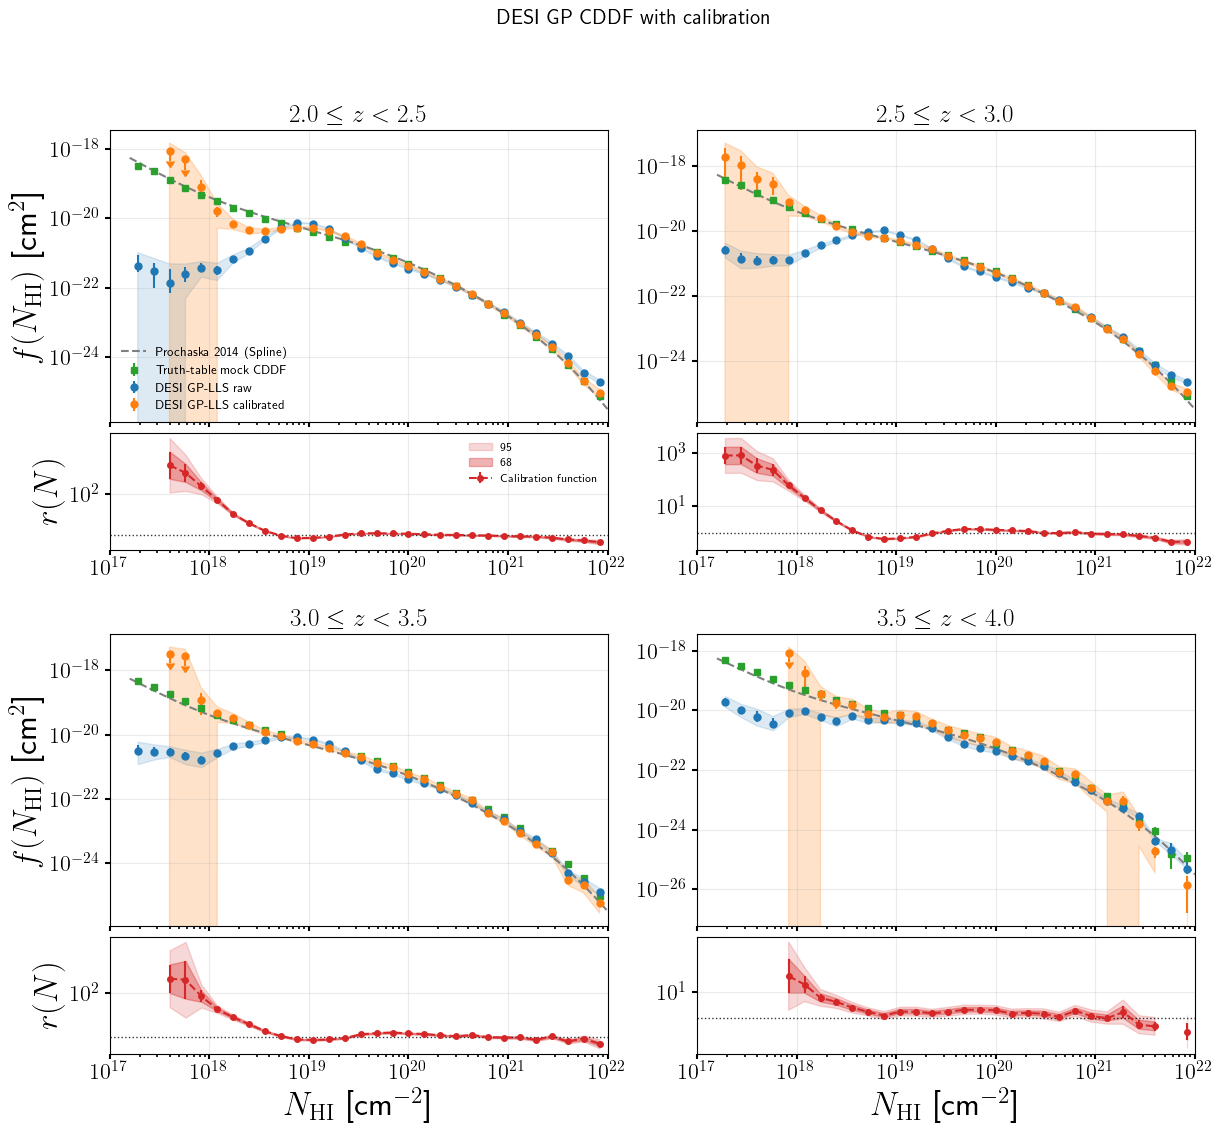

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# Assumes these already exist from previous cells:
#
# truth/mock correction side:
#   r_mock_z25,  sig_r_mock_z25
#   r_mock_z253, sig_r_mock_z253
#   r_mock_z335, sig_r_mock_z335
#   r_mock_z354, sig_r_mock_z354
#
# truth-table CDDF side:
#   cddf_lls["logN_mid"], cddf_lls["fN"], cddf_lls["err_boot"] / ["err_poisson"]
#   f_true_z25,  sig_true_z25
#   f_true_z253, sig_true_z253
#   f_true_z335, sig_true_z335
#   f_true_z354, sig_true_z354
#
# correction/apply helpers from previous cell:
#   sigma_from_interval
#   apply_correction_with_uncertainty
#
# P14 spline function:
#   f_cddf(logN)
# ============================================================


# ----------------------------
# helper: correction interval in log-space
# ----------------------------
def make_log_interval(y, sigma, nsig=1.0):
    """
    Build multiplicative interval in log-space:
        log10 y ± nsig * sigma_log10
    """
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    out = np.full((len(y), 2), np.nan, dtype=float)
    m = np.isfinite(y) & np.isfinite(sigma) & (y > 0)

    sigma_log10 = np.zeros_like(y)
    sigma_log10[m] = sigma[m] / (y[m] * np.log(10.0))

    out[m, 0] = 10 ** (np.log10(y[m]) - nsig * sigma_log10[m])
    out[m, 1] = 10 ** (np.log10(y[m]) + nsig * sigma_log10[m])
    return out


# ----------------------------
# measured DESI LLS uncertainties from loaded files
# ----------------------------
sig68_lls_z2025  = sigma_from_interval(cddf_lls_z2025,  cddf68_lls_z2025)
sig68_lls_z2530   = sigma_from_interval(cddf_lls_z2530,   cddf68_lls_z2530)
sig68_lls_z3035 = sigma_from_interval(cddf_lls_z3035, cddf68_lls_z3035)
sig68_lls_z3540  = sigma_from_interval(cddf_lls_z3540,  cddf68_lls_z3540)

# ----------------------------
# apply the new correction function to DESI LLS measurements
# ----------------------------
cddf_lls_z2025_corr, sig_lls_z2025_corr, cddf68_lls_z2025_corr = apply_correction_with_uncertainty(
    cddf_lls_z2025, sig68_lls_z2025, r_mock_z2025, sig_r_mock_z2025, nsig=1.0
)
_, _, cddf95_lls_z2025_corr = apply_correction_with_uncertainty(
    cddf_lls_z2025, sig68_lls_z2025, r_mock_z2025, sig_r_mock_z2025, nsig=2.0
)

cddf_lls_z2530_corr, sig_lls_z2530_corr, cddf68_lls_z2530_corr = apply_correction_with_uncertainty(
    cddf_lls_z2530, sig68_lls_z2530, r_mock_z2530, sig_r_mock_z2530, nsig=1.0
)
_, _, cddf95_lls_z2530_corr = apply_correction_with_uncertainty(
    cddf_lls_z2530, sig68_lls_z2530, r_mock_z2530, sig_r_mock_z2530, nsig=2.0
)

cddf_lls_z3035_corr, sig_lls_z3035_corr, cddf68_lls_z3035_corr = apply_correction_with_uncertainty(
    cddf_lls_z3035, sig68_lls_z3035, r_mock_z3035, sig_r_mock_z3035, nsig=1.0
)
_, _, cddf95_lls_z3035_corr = apply_correction_with_uncertainty(
    cddf_lls_z3035, sig68_lls_z3035, r_mock_z3035, sig_r_mock_z3035, nsig=2.0
)

cddf_lls_z3540_corr, sig_lls_z3540_corr, cddf68_lls_z3540_corr = apply_correction_with_uncertainty(
    cddf_lls_z3540, sig68_lls_z3540, r_mock_z3540, sig_r_mock_z3540, nsig=1.0
)
_, _, cddf95_lls_z3540_corr = apply_correction_with_uncertainty(
    cddf_lls_z3540, sig68_lls_z3540, r_mock_z3540, sig_r_mock_z3540, nsig=2.0
)

# ----------------------------
# correction-function intervals
# ----------------------------
r68_z2025  = make_log_interval(r_mock_z2025,  sig_r_mock_z2025,  nsig=1.0)
r95_z2025  = make_log_interval(r_mock_z2025,  sig_r_mock_z2025,  nsig=2.0)

r68_z2530   = make_log_interval(r_mock_z2530, sig_r_mock_z2530, nsig=1.0)
r95_z2530   = make_log_interval(r_mock_z2530, sig_r_mock_z2530, nsig=2.0)

r68_z3035 = make_log_interval(r_mock_z3035, sig_r_mock_z3035, nsig=1.0)
r95_z3035 = make_log_interval(r_mock_z3035, sig_r_mock_z3035, nsig=2.0)

r68_z3540  = make_log_interval(r_mock_z3540, sig_r_mock_z3540, nsig=1.0)
r95_z3540  = make_log_interval(r_mock_z3540, sig_r_mock_z3540, nsig=2.0)

# ----------------------------
# package by redshift bin
# ----------------------------
panel_data = [
    dict(
        title=r"$2.0 \le z < 2.5$",
        logN=l_N_lls_z2025,
        f_raw=cddf_lls_z2025,
        f68_raw=cddf68_lls_z2025,
        f95_raw=cddf95_lls_z2025,
        f_corr=cddf_lls_z2025_corr,
        f68_corr=cddf68_lls_z2025_corr,
        f95_corr=cddf95_lls_z2025_corr,
        f_true=f_true_z2025,
        sig_true=sig_true_z2025,
        r=r_mock_z2025,
        r68=r68_z2025,
        r95=r95_z2025,
    ),
    dict(
        title=r"$2.5 \le z < 3.0$",
        logN=l_N_lls_z2530,
        f_raw=cddf_lls_z2530,
        f68_raw=cddf68_lls_z2530,
        f95_raw=cddf95_lls_z2530,
        f_corr=cddf_lls_z2530_corr,
        f68_corr=cddf68_lls_z2530_corr,
        f95_corr=cddf95_lls_z2530_corr,
        f_true=f_true_z2530,
        sig_true=sig_true_z2530,
        r=r_mock_z2530,
        r68=r68_z2530,
        r95=r95_z2530,
    ),
    dict(
        title=r"$3.0 \le z < 3.5$",
        logN=l_N_lls_z3035,
        f_raw=cddf_lls_z3035,
        f68_raw=cddf68_lls_z3035,
        f95_raw=cddf95_lls_z3035,
        f_corr=cddf_lls_z3035_corr,
        f68_corr=cddf68_lls_z3035_corr,
        f95_corr=cddf95_lls_z3035_corr,
        f_true=f_true_z3035,
        sig_true=sig_true_z3035,
        r=r_mock_z3035,
        r68=r68_z3035,
        r95=r95_z3035,
    ),
    dict(
        title=r"$3.5 \le z < 4.0$",
        logN=l_N_lls_z3540,
        f_raw=cddf_lls_z3540,
        f68_raw=cddf68_lls_z3540,
        f95_raw=cddf95_lls_z3540,
        f_corr=cddf_lls_z3540_corr,
        f68_corr=cddf68_lls_z3540_corr,
        f95_corr=cddf95_lls_z3540_corr,
        f_true=f_true_z3540,
        sig_true=sig_true_z3540,
        r=r_mock_z3540,
        r68=r68_z3540,
        r95=r95_z3540,
    ),
]

# ----------------------------
# P14 reference
# ----------------------------
logN_plot = np.linspace(17.2, 22.0, 500)
N_plot = 10 ** logN_plot
f_p14 = f_cddf(logN_plot)

# ----------------------------
# build 2x2 panel figure, each panel has top CDDF + bottom correction
# ----------------------------
fig = plt.figure(figsize=(14, 12))
outer = GridSpec(2, 2, figure=fig, wspace=0.18, hspace=0.20)

for i, d in enumerate(panel_data):
    sub = outer[i].subgridspec(2, 1, height_ratios=[3.0, 1.2], hspace=0.05)
    ax_top = fig.add_subplot(sub[0])
    ax_bot = fig.add_subplot(sub[1], sharex=ax_top)

    N = 10 ** d["logN"]
    ind = d["logN"] < 22.0  # only plot up to 1e22 cm^-2 for now

    # ---------- TOP: CDDF ----------
    ax_top.plot(
        N_plot, f_p14,
        color="0.5", linestyle="--", lw=1.5,
        label="Prochaska 2014 (Spline)" if i == 0 else None,
    )

    # truth-table CDDF
    ax_top.errorbar(
        10 ** cddf_lls["logN_mid"],
        d["f_true"],
        yerr=d["sig_true"],
        fmt="s",
        ms=4,
        color="C2",
        label="Truth-table mock CDDF" if i == 0 else None,
    )

    # raw DESI LLS
    ax_top.errorbar(
        N[ind],
        d["f_raw"][ind],
        yerr=[
            d["f_raw"][ind] - d["f68_raw"][ind, 0],
            d["f68_raw"][ind, 1] - d["f_raw"][ind],
        ],
        fmt="o",
        color="C0",
        ms=5,
        label="DESI GP-LLS raw" if i == 0 else None,
    )
    ax_top.fill_between(
        N[ind],
        d["f95_raw"][ind, 0],
        d["f95_raw"][ind, 1],
        color="C0",
        alpha=0.15,
    )

    # corrected DESI LLS
    i_det = (d["f68_corr"][:, 0] > 0) & ind
    i_lim = (d["f68_corr"][:, 0] <= 0) & ind

    ax_top.errorbar(
        N[i_det],
        d["f_corr"][i_det],
        yerr=[
            d["f_corr"][i_det] - d["f68_corr"][i_det, 0],
            d["f68_corr"][i_det, 1] - d["f_corr"][i_det],
        ],
        fmt="o",
        color="C1",
        ms=5,
        label="DESI GP-LLS calibrated" if i == 0 else None,
    )

    if np.any(i_lim):
        y_lim = d["f68_corr"][i_lim, 1]
        cap = 0.5 * np.maximum(y_lim, 1e-99)
        ax_top.errorbar(
            N[i_lim],
            y_lim,
            yerr=cap,
            fmt="o",
            uplims=True,
            color="C1",
            ms=5,
        )

    ax_top.fill_between(
        N[ind],
        d["f95_corr"][ind, 0],
        d["f95_corr"][ind, 1],
        color="C1",
        alpha=0.22,
    )

    ax_top.set_xscale("log")
    ax_top.set_yscale("log")
    ax_top.set_xlim(1e17, 1e22)
    ax_top.grid(True, alpha=0.25)
    ax_top.set_title(d["title"])
    ax_top.tick_params(axis="x", labelbottom=False)

    # ---------- BOTTOM: correction function ----------
    ax_bot.fill_between(
        N[ind],
        d["r95"][ind, 0],
        d["r95"][ind, 1],
        color="C3",
        alpha=0.18,
        label="95%" if i == 0 else None,
    )
    ax_bot.fill_between(
        N[ind],
        d["r68"][ind, 0],
        d["r68"][ind, 1],
        color="C3",
        alpha=0.35,
        label="68%" if i == 0 else None,
    )
    ax_bot.errorbar(
        N[ind],
        d["r"][ind],
        yerr=[
            d["r"][ind] - d["r68"][ind, 0],
            d["r68"][ind, 1] - d["r"][ind],
        ],
        fmt="o",
        color="C3",
        ms=4,
        linestyle="--",
        label="Calibration function" if i == 0 else None,
    )
    ax_bot.axhline(1.0, color="black", linestyle=":", lw=1.0, alpha=0.8)
    ax_bot.set_xscale("log")
    ax_bot.set_yscale("log")
    ax_bot.set_xlim(1e17, 1e22)
    ax_bot.grid(True, alpha=0.25)

    if i in (2, 3):
        ax_bot.set_xlabel(r"$N_{\mathrm{HI}}$ [cm$^{-2}$]")

    if i in (0, 2):
        ax_top.set_ylabel(r"$f(N_{\mathrm{HI}})$ [cm$^{2}$]")
        ax_bot.set_ylabel(r"$r(N)$")

    if i == 0:
        ax_top.legend(loc="lower left", fontsize=9, frameon=False)
        ax_bot.legend(loc="best", fontsize=8, frameon=False)

fig.suptitle("DESI GP CDDF with calibration", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "/Users/jibanmac/Documents/Latex/gp_dla_desi_y3/figures/cddf_completeness_correction_grid.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
    pad_inches=0.1,
    facecolor="white",
    edgecolor="none",
    format="pdf",
)

plt.show()

## Save the FN table into txt

In [22]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt


def _sanitize_title_to_tag(title):
    """
    Convert a panel title like r"$2.0 \\le z < 2.5$" into a safe tag like z2025.
    """
    s = str(title)
    nums = re.findall(r"\d+\.\d+", s)
    if len(nums) >= 2:
        a = nums[0].replace(".", "")
        b = nums[1].replace(".", "")
        return f"z{a}{b}"
    return "zbin"


def save_cddf_txt_table(outpath, d, include_truth=True):
    """
    Save one redshift-bin CDDF table in linear space.

    Column order:
      logN,
      calibrated CDDF first,
      raw CDDF second,
      calibration function third,
      optional truth last.

    Saved columns:
      logN
      f_cal
      f_cal_68_lo
      f_cal_68_hi
      f_cal_95_lo
      f_cal_95_hi
      f_raw
      f_raw_68_lo
      f_raw_68_hi
      f_raw_95_lo
      f_raw_95_hi
      r_cal
      r_68_lo
      r_68_hi
      r_95_lo
      r_95_hi
      [optional]
      f_true_mock
      sigma_true_mock
    """
    logN = np.asarray(d["logN"], dtype=float)

    cols = [
        logN,

        # calibrated first
        np.asarray(d["f_corr"], dtype=float),
        np.asarray(d["f68_corr"][:, 0], dtype=float),
        np.asarray(d["f68_corr"][:, 1], dtype=float),
        np.asarray(d["f95_corr"][:, 0], dtype=float),
        np.asarray(d["f95_corr"][:, 1], dtype=float),

        # raw second
        np.asarray(d["f_raw"], dtype=float),
        np.asarray(d["f68_raw"][:, 0], dtype=float),
        np.asarray(d["f68_raw"][:, 1], dtype=float),
        np.asarray(d["f95_raw"][:, 0], dtype=float),
        np.asarray(d["f95_raw"][:, 1], dtype=float),

        # calibration function
        np.asarray(d["r"], dtype=float),
        np.asarray(d["r68"][:, 0], dtype=float),
        np.asarray(d["r68"][:, 1], dtype=float),
        np.asarray(d["r95"][:, 0], dtype=float),
        np.asarray(d["r95"][:, 1], dtype=float),
    ]

    names = [
        "logN",

        "f_cal",
        "f_cal_68_lo",
        "f_cal_68_hi",
        "f_cal_95_lo",
        "f_cal_95_hi",

        "f_raw",
        "f_raw_68_lo",
        "f_raw_68_hi",
        "f_raw_95_lo",
        "f_raw_95_hi",

        "r_cal",
        "r_68_lo",
        "r_68_hi",
        "r_95_lo",
        "r_95_hi",
    ]

    if include_truth:
        cols.extend([
            np.asarray(d["f_true"], dtype=float),
            np.asarray(d["sig_true"], dtype=float),
        ])
        names.extend([
            "f_true_mock",
            "sigma_true_mock",
        ])

    arr = np.column_stack(cols)

    header_lines = [
        f"title: {d.get('title', 'unknown')}",
        "columns: " + " ".join(names),
        "notes: values stored in linear space; calibrated CDDF saved first, raw CDDF second, calibration function included; 68/95 columns are lower/upper bounds",
    ]
    header = "\n".join(header_lines)

    np.savetxt(outpath, arr, header=header, fmt="%.8e")
    print(f"Saved: {outpath}")


def save_all_cddf_txt_tables(panel_data, outdir, prefix="cddf_lls_calibrated", include_truth=True):
    """
    Save all redshift-bin tables from panel_data into one directory.
    One file per z bin.
    """
    os.makedirs(outdir, exist_ok=True)

    for d in panel_data:
        tag = _sanitize_title_to_tag(d.get("title", "zbin"))
        outpath = os.path.join(outdir, f"{prefix}_{tag}.txt")
        save_cddf_txt_table(outpath, d, include_truth=include_truth)


def load_cddf_txt_table(path):
    """
    Load a saved txt table back into a dict with named columns.
    """
    with open(path, "r") as f:
        header_lines = [line.strip() for line in f if line.startswith("#")]

    col_line = None
    title = None
    for line in header_lines:
        s = line.lstrip("#").strip()
        if s.startswith("columns:"):
            col_line = s
        if s.startswith("title:"):
            title = s.replace("title:", "").strip()

    if col_line is None:
        raise ValueError(f"Could not find 'columns:' header in {path}")

    colnames = col_line.replace("columns:", "").strip().split()
    data = np.loadtxt(path)

    out = {"title": title, "path": path}
    for i, name in enumerate(colnames):
        out[name] = data[:, i]
    return out


def plot_cddf_from_txt(path, ax=None, show=True, plot_truth=True, plot_ratio=True):
    """
    Simple test plot from one saved txt file.
    Uses calibrated-first convention.
    """
    d = load_cddf_txt_table(path)

    if plot_ratio:
        if ax is None:
            fig, (ax1, ax2) = plt.subplots(
                2, 1,
                figsize=(6, 7),
                sharex=True,
                gridspec_kw={"height_ratios": [3, 1.2]}
            )
        else:
            raise ValueError("If plot_ratio=True, let the function create its own figure.")
    else:
        if ax is None:
            fig, ax1 = plt.subplots(figsize=(6, 5))
        else:
            ax1 = ax

    N = 10 ** d["logN"]

    # calibrated first
    ax1.errorbar(
        N,
        d["f_cal"],
        yerr=[d["f_cal"] - d["f_cal_68_lo"], d["f_cal_68_hi"] - d["f_cal"]],
        fmt="o",
        ms=5,
        color="C1",
        label="calibrated",
    )
    ax1.fill_between(
        N,
        d["f_cal_95_lo"],
        d["f_cal_95_hi"],
        color="C1",
        alpha=0.20,
    )

    # raw second
    ax1.errorbar(
        N,
        d["f_raw"],
        yerr=[d["f_raw"] - d["f_raw_68_lo"], d["f_raw_68_hi"] - d["f_raw"]],
        fmt="o",
        ms=5,
        color="C0",
        label="raw",
    )
    ax1.fill_between(
        N,
        d["f_raw_95_lo"],
        d["f_raw_95_hi"],
        color="C0",
        alpha=0.15,
    )

    if plot_truth and ("f_true_mock" in d):
        ax1.errorbar(
            N,
            d["f_true_mock"],
            yerr=d["sigma_true_mock"],
            fmt="s",
            ms=4,
            color="C2",
            label="truth mock",
        )

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel(r"$N_{\mathrm{HI}}$ [cm$^{-2}$]")
    ax1.set_xlim(1e17, 1e22)
    ax1.set_ylabel(r"$f(N_{\mathrm{HI}})$")
    ax1.set_title(d.get("title", os.path.basename(path)))
    ax1.grid(True, alpha=0.3)
    ax1.legend(frameon=False)

    if plot_ratio and ("r_cal" in d):
        ax2.fill_between(
            N,
            d["r_95_lo"],
            d["r_95_hi"],
            color="C3",
            alpha=0.18,
        )
        ax2.fill_between(
            N,
            d["r_68_lo"],
            d["r_68_hi"],
            color="C3",
            alpha=0.35,
        )
        ax2.errorbar(
            N,
            d["r_cal"],
            yerr=[d["r_cal"] - d["r_68_lo"], d["r_68_hi"] - d["r_cal"]],
            fmt="o",
            ms=4,
            color="C3",
            label="calibration",
        )
        ax2.axhline(1.0, color="black", linestyle=":", lw=1.0)
        ax2.set_xscale("log")
        ax2.set_yscale("log")
        ax2.set_xlim(1e17, 1e22)
        ax2.set_xlabel(r"$N_{\mathrm{HI}}$ [cm$^{-2}$]")
        ax2.set_ylabel(r"$r(N)$")
        ax2.grid(True, alpha=0.3)

    if show:
        plt.show()

    return d

In [27]:
outdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables"

save_all_cddf_txt_tables(
    panel_data,
    outdir=outdir,
    prefix="desi_snr6_gp_lls_calibrated",
    include_truth=True,
)

Saved: /Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_snr6_gp_lls_calibrated_z2025.txt
Saved: /Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_snr6_gp_lls_calibrated_z2530.txt
Saved: /Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_snr6_gp_lls_calibrated_z3035.txt
Saved: /Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_snr6_gp_lls_calibrated_z3540.txt


dict_keys(['title', 'path', 'logN', 'f_cal', 'f_cal_68_lo', 'f_cal_68_hi', 'f_cal_95_lo', 'f_cal_95_hi', 'f_raw', 'f_raw_68_lo', 'f_raw_68_hi', 'f_raw_95_lo', 'f_raw_95_hi', 'r_cal', 'r_68_lo', 'r_68_hi', 'r_95_lo', 'r_95_hi', 'f_true_mock', 'sigma_true_mock'])


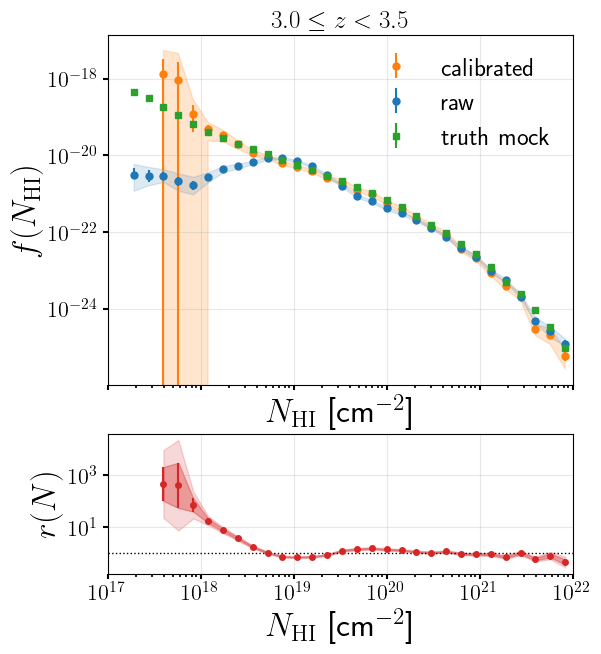

{'title': '$3.0 \\le z < 3.5$',
 'path': '/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_gp_lls_calibrated_z3035.txt',
 'logN': array([17.28, 17.44, 17.6 , 17.76, 17.92, 18.08, 18.24, 18.4 , 18.56,
        18.72, 18.88, 19.04, 19.2 , 19.36, 19.52, 19.68, 19.84, 20.  ,
        20.16, 20.32, 20.48, 20.64, 20.8 , 20.96, 21.12, 21.28, 21.44,
        21.6 , 21.76, 21.92]),
 'f_cal': array([           nan,            nan, 1.32849958e-18, 9.02170723e-19,
        1.20428693e-19, 4.82176254e-20, 3.39328586e-20, 1.94205055e-20,
        1.16550036e-20, 8.87187500e-21, 6.30839833e-21, 5.00999873e-21,
        3.82498013e-21, 2.60043353e-21, 2.07024577e-21, 1.27786412e-21,
        9.77487235e-22, 5.80281111e-22, 4.06354528e-22, 2.38933136e-22,
        1.39109427e-22, 9.03706787e-23, 3.60324288e-23, 2.09618379e-23,
        8.78260044e-24, 4.00917738e-24, 2.13552728e-24, 2.96242436e-25,
        2.12602545e-25, 5.78568718e-26]),
 'f_cal_68_lo': array([           n

In [26]:
test_path = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_saved_tables/desi_gp_lls_calibrated_z3035.txt"

d_test = load_cddf_txt_table(test_path)
print(d_test.keys())

plot_cddf_from_txt(test_path, plot_truth=True, plot_ratio=True)

## CDDF comparison plot

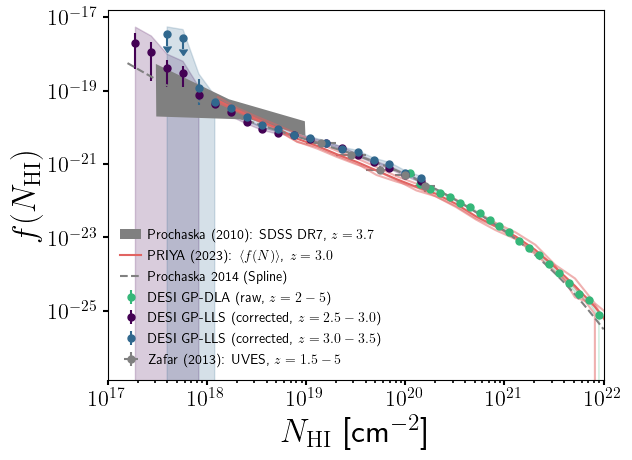

In [19]:
# ============================================================
# CDDF plot with two LLS corrected curves:
#   - z = 2.5 - 3.0
#   - z = 3.0 - 3.5
# using the NEW truth-table-based correction function
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob

# ----------------------------
# DESI Y3 DLA (raw, z = 2-5)
# ----------------------------
nhi = 10**l_N
plt.errorbar(
    nhi,
    cddf,
    yerr=[cddf - cddf68[:, 0], cddf68[:, 1] - cddf],
    fmt="o",
    color=c_skyline,
    ms=5,
    label="DESI GP-DLA (raw, $z = 2-5$)",
)
plt.fill_between(
    nhi,
    cddf95[:, 0],
    cddf95[:, 1],
    color=c_skyline,
    alpha=0.2,
)

# ============================================================
# LLS: z = 2.5 - 3.0
# uses:
#   l_N_lls_z2530, cddf_lls_z2530, cddf68_lls_z2530, cddf95_lls_z2530
#   r_mock_z2530, sig_r_mock_z2530
# ============================================================
sig68_lls_z25 = sigma_from_interval(cddf_lls_z2530, cddf68_lls_z2530)

cddf_lls_z25_corrected, sig_lls_z25_corrected, cddf68_lls_z25_corrected = apply_correction_with_uncertainty(
    cddf_lls_z2530,
    sig68_lls_z2530,
    r_mock_z2530,
    sig_r_mock_z2530,
    nsig=1.0,
)
_, _, cddf95_lls_z25_corrected = apply_correction_with_uncertainty(
    cddf_lls_z2530,
    sig68_lls_z2530,
    r_mock_z2530,
    sig_r_mock_z2530,
    nsig=2.0,
)

nhi_lls_z25 = 10**l_N_lls_z2530
ind = l_N_lls_z2530 < 20.3

i_det = (cddf68_lls_z25_corrected[:, 0] > 0) & ind
plt.errorbar(
    nhi_lls_z25[i_det],
    cddf_lls_z25_corrected[i_det],
    yerr=(
        cddf_lls_z25_corrected[i_det] - cddf68_lls_z25_corrected[i_det, 0],
        cddf68_lls_z25_corrected[i_det, 1] - cddf_lls_z25_corrected[i_det],
    ),
    fmt="o",
    color=c_flatirons,
    ms=5,
    label="DESI GP-LLS (corrected, $z=2.5-3.0$)",
)

i_lim = (cddf68_lls_z25_corrected[:, 0] <= 0) & ind
if np.any(i_lim):
    y_lim = cddf68_lls_z25_corrected[i_lim, 1]
    cap = 0.5 * np.maximum(y_lim, 1e-99)
    plt.errorbar(
        nhi_lls_z25[i_lim],
        y_lim,
        yerr=cap,
        fmt="o",
        uplims=True,
        color=c_flatirons,
        ms=5,
        label=None,
    )

plt.fill_between(
    nhi_lls_z25[ind],
    cddf95_lls_z25_corrected[ind, 0],
    cddf95_lls_z25_corrected[ind, 1],
    color=c_flatirons,
    alpha=0.2,
)

# ============================================================
# LLS: z = 3.0 - 3.5
# uses:
#   l_N_lls_z3035, cddf_lls_z3035, cddf68_lls_z3035, cddf95_lls_z3035
#   r_mock_z335, sig_r_mock_z335
# ============================================================
sig68_lls_z3035 = sigma_from_interval(cddf_lls_z3035, cddf68_lls_z3035)

cddf_lls_z3035_corrected, sig_lls_z3035_corrected, cddf68_lls_z3035_corrected = apply_correction_with_uncertainty(
    cddf_lls_z3035,
    sig68_lls_z3035,
    r_mock_z3035,
    sig_r_mock_z3035,
    nsig=1.0,
)
_, _, cddf95_lls_z3035_corrected = apply_correction_with_uncertainty(
    cddf_lls_z3035,
    sig68_lls_z3035,
    r_mock_z3035,
    sig_r_mock_z3035,
    nsig=2.0,
)

nhi_lls_z3035 = 10**l_N_lls_z3035
ind = l_N_lls_z3035 < 20.3

i_det = (cddf68_lls_z3035_corrected[:, 0] > 0) & ind
plt.errorbar(
    nhi_lls_z3035[i_det],
    cddf_lls_z3035_corrected[i_det],
    yerr=(
        cddf_lls_z3035_corrected[i_det] - cddf68_lls_z3035_corrected[i_det, 0],
        cddf68_lls_z3035_corrected[i_det, 1] - cddf_lls_z3035_corrected[i_det],
    ),
    fmt="o",
    color=c_midnight,
    ms=5,
    label="DESI GP-LLS (corrected, $z=3.0-3.5$)",
)

i_lim = (cddf68_lls_z3035_corrected[:, 0] <= 0) & ind
if np.any(i_lim):
    y_lim = cddf68_lls_z3035_corrected[i_lim, 1]
    cap = 0.5 * np.maximum(y_lim, 1e-99)
    plt.errorbar(
        nhi_lls_z3035[i_lim],
        y_lim,
        yerr=cap,
        fmt="o",
        uplims=True,
        color=c_midnight,
        ms=5,
        label=None,
    )

plt.fill_between(
    nhi_lls_z3035[ind],
    cddf95_lls_z3035_corrected[ind, 0],
    cddf95_lls_z3035_corrected[ind, 1],
    color=c_midnight,
    alpha=0.2,
)

# ----------------------------
# External data
# ----------------------------
zafar_data(moment=False, label="Zafar (2013): UVES, $z=1.5-5$")
prochaska_10_data(moment=False, label="Prochaska (2010): SDSS DR7, $z=3.7$")

# ----------------------------
# Load the CDDF from PRIYA
# ----------------------------
all_files = glob.glob("/Users/jibanmac/Documents/GitHub/lya_emu_xq100/priya_cddf/*-2.2.txt")
cddf_data = []
nhi_bins = []
for f in all_files:
    nhi_bins.append(np.loadtxt(f)[0])
    cddf_data.append(np.loadtxt(f)[1])

all_files_3 = glob.glob("/Users/jibanmac/Documents/GitHub/lya_emu_xq100/priya_cddf/*-3.0.txt")
cddf_data_3 = []
nhi_bins_3 = []
for f in all_files_3:
    nhi_bins_3.append(np.loadtxt(f)[0])
    cddf_data_3.append(np.loadtxt(f)[1])

all_files_4 = glob.glob("/Users/jibanmac/Documents/GitHub/lya_emu_xq100/priya_cddf/*-4.0.txt")
cddf_data_4 = []
nhi_bins_4 = []
for f in all_files_4:
    nhi_bins_4.append(np.loadtxt(f)[0])
    cddf_data_4.append(np.loadtxt(f)[1])

nhi_bins = np.array(nhi_bins)
cddf_data = np.array(cddf_data)
nhi_bins_3 = np.array(nhi_bins_3)
cddf_data_3 = np.array(cddf_data_3)
nhi_bins_4 = np.array(nhi_bins_4)
cddf_data_4 = np.array(cddf_data_4)

plt.plot(
    nhi_bins_3[0],
    cddf_data_3[:].mean(axis=0),
    color=matplotlib.cm.plasma(0.6),
    label=r"PRIYA (2023): $\langle f(N) \rangle$, $z=3.0$",
)

for i in range(len(cddf_data_3)):
    plt.plot(
        nhi_bins_3[i],
        cddf_data_3[i],
        color=matplotlib.cm.plasma(0.6),
        alpha=0.5,
    )

# ----------------------------
# Prochaska et al. 2014 spline
# ----------------------------
logN_plot = np.linspace(17.2, 22.0, 500)
plt.loglog(
    10**logN_plot,
    f_cddf(logN_plot),
    label="Prochaska 2014 (Spline)",
    color="grey",
    linestyle="--",
)

# ----------------------------
# styling
# ----------------------------
plt.xlabel("$N_\\mathrm{HI}$ [cm$^{-2}$]")
plt.ylabel("$f(N_\\mathrm{HI})$")
plt.xlim(1e17, 1e22)

plt.legend(
    loc="lower left",
    fontsize=10,
    frameon=False,
    handlelength=1.5,
    handletextpad=0.5,
)

plt.savefig(
    "/Users/jibanmac/Documents/Latex/gp_dla_desi_y3/figures/cddf_completeness_correction_z253_z3035.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
    pad_inches=0.1,
    facecolor="white",
    edgecolor="none",
    format="pdf",
)

## OmegaNHI


subDLA (compare with Zafar 13 and Berg XQ100 2019)

In [20]:
def plot_omega_dla(
    z_cent: np.ndarray,
    omega_dla: np.ndarray,
    omega_dla_68: np.ndarray,
    omega_dla_95: np.ndarray,
    zmin: float = 2.0,
    zmax: float = 5.5,
    label: str = "GP",
    color: str = "blue",
    twosigma: bool = True,
    bins_per_z: int = 6,
    ylabel: str = r"$10^3 \times \Omega_\mathrm{subDLA}$",
):
    """Plot omega_DLA as a function of redshift, with full Bayesian errors"""
    nbins = np.max([int((zmax - zmin) * bins_per_z), 1])
    z_bins = np.linspace(zmin, zmax, nbins + 1)

    try:
        # hope this line works
        xerrs = (z_cent - z_bins[:-1], z_bins[1:] - z_cent)
    except ValueError as e:
        xerrs = (z_cent - z_bins[:-2], z_bins[1:-1] - z_cent)

    # import pdb
    # pdb.set_trace()

    if twosigma:
        plt.fill_between(
            z_cent,
            1000 * omega_dla_95[:, 0],
            1000 * omega_dla_95[:, 1],
            color="grey",
            alpha=0.5,
        )
    yerr = (
        omega_dla - 1000 * omega_dla_68[:, 0],
        1000 * omega_dla_68[:, 1] - omega_dla,
    )
    plt.errorbar(
        z_cent, omega_dla, yerr=yerr, xerr=xerrs, fmt="s", label=label, color=color
    )
    plt.xlabel(r"z")
    plt.ylabel(ylabel)
    plt.xlim(zmin, zmax)


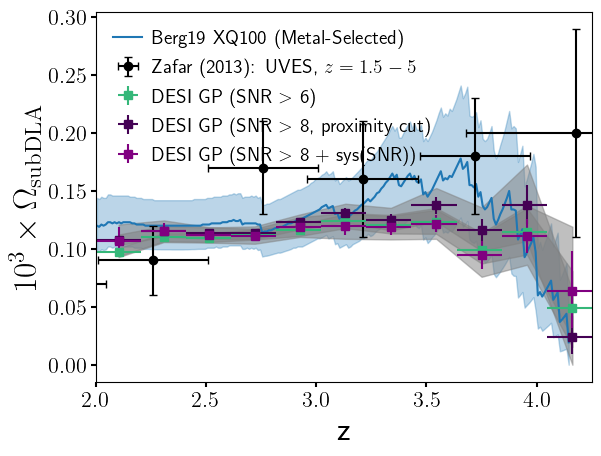

In [21]:
# dla_data.xq100_omega(scaling=1000.0, subdla=True, label="Berg19 XQ100 ")

import pandas as pd

df = pd.read_csv("../../DLA_data/omega_hi_tableB4_metal_selected_sample.csv")

z = df["z"].values

# subDLAs
sub_med = df["OmegaHI_sub_med"].values * 1000.0
sub_lo  = df["OmegaHI_sub_p17"].values * 1000.0
sub_hi  = df["OmegaHI_sub_p83"].values * 1000.0

plt.plot(z, sub_med, label="Berg19 XQ100 (Metal-Selected)", color="C0")
plt.fill_between(z, sub_lo, sub_hi, alpha=0.3, color="C0")


# Zafar et al. 2013
dtype = [
    ("z_min", float),
    ("z_max", float),
    ("z_mean_DLA", float),
    ("dz_DLA", float),
    ("dX_DLA", float),
    ("Omega_DLA_1e3", float),
    ("Omega_DLA_err_1e3", float),
    ("N_DLA", int),
    ("z_mean_sub", float),
    ("dz_sub", float),
    ("dX_sub", float),
    ("Omega_sub_1e3", float),
    ("Omega_sub_err_1e3", float),
    ("N_sub", int),
    ("Omega_g_total_1e3", float),
    ("Omega_g_err_1e3", float),
    ("rho_g_1e8", float),
    ("rho_g_err_1e8", float),
]

table = np.array([
    (1.51, 2.00, 1.84, 95.6, 279.4, 0.83, 0.24, 21, 1.80, 29.9,  87.3, 0.07, 0.03,  4, 0.90, 0.20, 1.23, 0.33),
    (2.00, 2.50, 2.27,125.1, 396.6, 0.90, 0.28, 26, 2.26, 49.2, 156.8, 0.09, 0.03, 11, 0.99, 0.29, 1.35, 0.38),
    (2.50, 3.00, 2.73, 87.2, 301.0, 0.96, 0.28, 18, 2.76, 47.1, 162.8, 0.17, 0.04, 24, 1.13, 0.28, 1.54, 0.38),
    (3.00, 3.50, 3.25, 64.8, 239.6, 1.00, 0.28, 18, 3.21, 33.7, 124.5, 0.16, 0.05, 23, 1.16, 0.29, 1.58, 0.39),
    (3.50, 4.00, 3.77, 49.5, 194.6, 0.75, 0.21, 19, 3.72, 23.3,  91.7, 0.18, 0.05, 19, 1.03, 0.21, 1.40, 0.29),
    (4.00, 5.00, 4.20, 23.2,  95.6, 0.76, 0.25, 10, 4.18,  9.9,  41.0, 0.20, 0.09,  8, 0.96, 0.25, 1.31, 0.36),
], dtype=dtype)

# x-axis: mean redshift of sub-DLAs
z = table["z_mean_sub"]
# x-error: half bin width
xerr = 0.5 * (table["z_max"] - table["z_min"])
# y-axis: Omega_sub-DLA
omega = table["Omega_sub_1e3"]
omega_err = table["Omega_sub_err_1e3"]

plt.errorbar(
    z, omega,
    xerr=xerr,
    yerr=omega_err,
    fmt="o",
    capsize=3,
    label="Zafar (2013): UVES, $z=1.5-5$",
    color="black",
)

# OmegaDLA: Fiducial
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr6.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3/"
omega_dla_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color=c_skyline, label="DESI GP (SNR $>$ 6)", bins_per_z=5, zmin=2, zmax=4.25)

## preserve to calc the sigma_snr effect
_omega_dla_lsnr = omega_dla
_omega_dla_68_lsnr = omega_dla_68
_omega_dla_95_lsnr = omega_dla_95

# OmegaDLA: Low-z cut
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_lowzcut_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3/"
omega_dla_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color=c_flatirons, label="DESI GP (SNR $>$ 8, proximity cut)", bins_per_z=5, zmin=2, zmax=4.25)
# preserve to calc the sigma_snr effect
_omega_dla_lsnr_lowzcut = omega_dla
_omega_dla_68_lsnr_lowzcut = omega_dla_68
_omega_dla_95_lsnr_lowzcut = omega_dla_95

# OmegaDLA: High SNR
subdir = "/Users/jibanmac/Documents/GitHub/desi_gpy_dla_detection_public/cddf_all/dla_cddf_20260107/desi_snr8.0_zqsos_2.15-5.0_dla_5.5_occam_1.0_dla_model_1_zminlyb_22.0_minobswave_3700.0_bins_5_lnhi_17.2-22.0_lnhi_dndx_19.0-20.3/"
omega_dla_all = np.loadtxt(os.path.join(subdir, "omega_dla_all.txt"))
(_, N) = omega_dla_all.shape

omega_dla_68 = np.full((N, 2), fill_value=np.nan)
omega_dla_95 = np.full((N, 2), fill_value=np.nan)
(
    z_cent,
    omega_dla,
    omega_dla_68[:, 0],
    omega_dla_68[:, 1],
    omega_dla_95[:, 0],
    omega_dla_95[:, 1],
) = omega_dla_all

# plot_omega_dla(z_cent, omega_dla, omega_dla_68, omega_dla_95, color=c_skyline, label="DESI GP (SNR $>$ 8)", bins_per_z=5, zmin=2, zmax=4.25)

####### Final plot with SNR systematic ########
## This reads as: “stat interval widened by a worst-case SNR shift.”
# conservative single “total” bound (linear add) 
delta_snr = np.abs(_omega_dla_lsnr - omega_dla) / 1000
# delta_proximity = np.abs(_omega_dla_lsnr_lowzcut - omega_dla) / 1000
# delta_snr += delta_proximity
omega_dla_68_with_snr = np.column_stack([
    omega_dla_68[:, 0] - delta_snr,   # lower bound moves down
    omega_dla_68[:, 1] + delta_snr,   # upper bound moves up
])
omega_dla_95_with_snr = np.column_stack([
    omega_dla_95[:, 0] - delta_snr,
    omega_dla_95[:, 1] + delta_snr,
])

plot_omega_dla(
    z_cent,
    omega_dla,
    omega_dla_68_with_snr,
    omega_dla_95_with_snr,
    color="purple",
    label="DESI GP (SNR $>$ 8 + sys(SNR))",
    bins_per_z=5,
    zmin=2,
    zmax=4.25,
)

plt.legend(
    loc="upper left",
    fontsize=14,
    frameon=False,
    # ncol=2,
    handlelength=1.5,
    handletextpad=0.5,
)

plt.savefig(
    os.path.join(outfile, "gp_desi_omegasubdla.png"),
    bbox_inches="tight",
    dpi=300,
    # fontsize=16,
    transparent=True,
    pad_inches=0.1,
    facecolor="white",
    edgecolor="none",
)